# Notebook 05 (Revised) — PLS-DA and SVM with 5-Fold Stratified Cross Validation
## CMSC 190 Special Problem — NIR Maize Protein Classifier

**Purpose:** Train and evaluate PLS-DA and SVM classifiers for High-Protein vs Low-Protein corn classification using NIR spectral data.

This notebook replaces the original `05_plsda_svm_training.ipynb`, which trained once on augmented data and evaluated on a fixed 16-sample test set. That approach is now replaced with **5-Fold Stratified Cross Validation (5-Fold CV)** to produce more reliable, generalizable performance estimates given the small dataset of 80 samples.

### Evaluation Strategy: 5-Fold Stratified Cross Validation
- The full dataset of **80 samples** is divided into 5 folds of 16 samples each
- Each outer fold yields **64 training samples** and **16 test samples**
- The 64 training samples are **augmented to 2000** using linear interpolation *inside the loop, before fitting*
- The 16 test samples are **never augmented** — they remain the original, real spectra
- This design ensures **zero data leakage** between folds: synthetic data derived from training samples never contaminates test evaluation
- Final reported metrics are the **mean ± standard deviation across all 5 folds**

---
## Section 1 — Imports and Setup

The following cell imports all required libraries. `sys.path.append('../..')` is added so that the custom modules in `src/` can be imported from this notebook's location. `interpolation_augment` handles spectral data augmentation, and `plot_confusion_matrix` renders the evaluation heatmaps.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Allow imports from the project root src/ directory
sys.path.append('../..')

from src.augmentor import interpolation_augment
from src.trainer import plot_confusion_matrix

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

# ── Reproducibility ──────────────────────────────────────────────────────────
random_state = 42

print("All libraries imported successfully.")
print(f"random_state set to {random_state}")

All libraries imported successfully.
random_state set to 42


---
## Section 2 — Load Full Dataset

We load the complete preprocessed NIR spectral matrix `X` (80 samples × 700 wavelength features) and the corresponding binary protein labels `y`. **No manual train/test split is performed here** — the 5-Fold CV loop in the next sections handles all splitting internally. Keeping all 80 samples together ensures the cross-validator can form properly sized, stratified folds.

In [2]:
# Load the full preprocessed dataset (no train/test split here)
X = np.load('../../data/processed/X_preprocessed.npy')
y = np.load('../../data/processed/y_labels.npy')

print("Dataset loaded successfully.")
print(f"X shape : {X.shape}   (samples × wavelength features)")
print(f"y shape : {y.shape}   (binary labels)")

print("\nClass distribution:")
classes, counts = np.unique(y, return_counts=True)
labels_map = {0: 'Low Protein  (0)', 1: 'High Protein (1)'}
for cls, cnt in zip(classes, counts):
    print(f"  {labels_map[cls]} : {cnt} samples ({cnt/len(y)*100:.1f}%)")

Dataset loaded successfully.
X shape : (549, 700)   (samples × wavelength features)
y shape : (549,)   (binary labels)

Class distribution:
  Low Protein  (0) : 255 samples (46.4%)
  High Protein (1) : 294 samples (53.6%)


---
## Section 3 — Define 5-Fold Stratified Cross Validation

`StratifiedKFold` is used instead of plain `KFold` to guarantee that **each fold preserves the original 50/50 class ratio**. With 80 samples and 5 folds, each test fold contains exactly 8 High-Protein and 8 Low-Protein samples, making per-fold evaluation metrics directly comparable across folds.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

print("StratifiedKFold defined.")
print(f"  n_splits     : {skf.n_splits}")
print(f"  shuffle      : {skf.shuffle}")
print(f"  random_state : {skf.random_state}")
print(f"\nEach outer fold → {len(X) - len(X)//5} training samples, {len(X)//5} test samples")

StratifiedKFold defined.
  n_splits     : 5
  shuffle      : True
  random_state : 42

Each outer fold → 440 training samples, 109 test samples


---
## Section 4 — PLS-DA 5-Fold Cross Validation

**Partial Least Squares Discriminant Analysis (PLS-DA)** is the standard chemometric classifier for NIR spectroscopy. It projects high-dimensional, collinear spectral data onto a small set of latent components that maximally explain the covariance between spectra and class labels. `PLSRegression` from scikit-learn is used and adapted for binary classification by thresholding continuous predictions at **0.5** (i.e., values ≥ 0.5 are assigned class 1 — High Protein).

The **number of latent components** (`n_components`) is a key hyperparameter. It is selected per fold using an **inner 10-fold cross validation** on the augmented training data, testing values from 1 to 20, and choosing the value that yields the highest mean F1-score. This nested approach prevents the component count from being tuned on the test fold.

### 4a — PLS-DA CV Loop

The outer loop iterates over the 5 folds. For each fold:
1. The training indices are used to extract `X_train_fold` and `y_train_fold`
2. Those 64 training samples are augmented to 2,000 via linear interpolation
3. An inner 10-fold CV on the augmented data selects the optimal `n_components`
4. A `PLSRegression` model is trained on the full augmented fold and evaluated on the 16 raw test samples
5. Per-fold metrics are recorded, and the model with the highest F1 is retained as the best

In [4]:

# ── Accumulators ─────────────────────────────────────────────────────────────
plsda_fold_metrics = []
plsda_best_model   = None
plsda_best_f1      = 0.0
plsda_all_y_true   = []
plsda_all_y_pred   = []

# ── Outer 5-Fold Loop ─────────────────────────────────────────────────────────
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    # 1. Split raw data into fold train / test
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # 2. Augment ONLY the training fold — test fold is never touched
    X_aug, y_aug = interpolation_augment(
        X_train_fold, y_train_fold,
        target_total=2000,
        random_state=random_state,
    )

    # 3. Inner 10-fold CV to select optimal n_components (1 → 20)
    candidate_scores = []
    for n in range(1, 21):
        pls_candidate = PLSRegression(n_components=n)
        # cross_val_score needs numeric y for PLSRegression; wrap prediction
        # using a custom scorer is complex, so we do it manually here
        inner_skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
        inner_f1s = []
        for in_tr, in_te in inner_skf.split(X_aug, y_aug):
            pls_candidate.fit(X_aug[in_tr], y_aug[in_tr])
            y_inner_pred = (pls_candidate.predict(X_aug[in_te]).ravel() >= 0.5).astype(int)
            inner_f1s.append(f1_score(y_aug[in_te], y_inner_pred, zero_division=0))
        candidate_scores.append(np.mean(inner_f1s))

    best_n = int(np.argmax(candidate_scores)) + 1   # +1 because range starts at 1

    # 4. Train final PLS-DA on full augmented fold with best n_components
    plsda = PLSRegression(n_components=best_n)
    plsda.fit(X_aug, y_aug)

    # 5. Predict on original (non-augmented) test fold
    y_pred = (plsda.predict(X_test_fold).ravel() >= 0.5).astype(int)

    # 6. Compute metrics
    acc  = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred, zero_division=0)
    rec  = recall_score(y_test_fold, y_pred, zero_division=0)
    f1   = f1_score(y_test_fold, y_pred, zero_division=0)

    print(
        f"Fold {fold+1}: "
        f"Accuracy={acc:.4f}  Precision={prec:.4f}  "
        f"Recall={rec:.4f}  F1={f1:.4f}  "
        f"(n_components={best_n})"
    )

    # 7. Store results
    plsda_fold_metrics.append({
        'accuracy': acc, 'precision': prec,
        'recall': rec,   'f1': f1,
    })
    plsda_all_y_true.append(y_test_fold)
    plsda_all_y_pred.append(y_pred)

    # 8. Keep the model from the fold with the highest F1
    if f1 > plsda_best_f1:
        plsda_best_f1    = f1
        plsda_best_model = plsda

print(f"\nBest PLS-DA fold F1 : {plsda_best_f1:.4f}")


Interpolation Augmentation
Original training size          : 439
Synthetic samples to generate   : 1561
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 943 samples
  1 (High Protein): 1057 samples
Fold 1: Accuracy=0.8727  Precision=0.8689  Recall=0.8983  F1=0.8833  (n_components=20)
Interpolation Augmentation
Original training size          : 439
Synthetic samples to generate   : 1561
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 942 samples
  1 (High Protein): 1058 samples
Fold 2: Accuracy=0.7909  Precision=0.8214  Recall=0.7797  F1=0.8000  (n_components=20)
Interpolation Augmentation
Original training size          : 439
Synthetic samples to generate   : 1561
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 949 samples
  1 (High Protein): 1051 samples
Fold 3: Accuracy=0.8091  Precision=0.8276  Recall=0.8136  F1=0.8

### 4b — PLS-DA Results Summary

The cell below computes the mean and standard deviation of each metric across the 5 folds and prints a formatted summary table. The confusion matrix below is built from the **concatenated predictions of all 5 test folds**, giving a global view of where the model succeeds and fails across the entire dataset.

  PLS-DA 5-Fold Cross Validation Results   
  Accuracy  : 0.8324 ± 0.0340
  Precision : 0.8383 ± 0.0174
  Recall    : 0.8503 ± 0.0563
  F1-Score  : 0.8437 ± 0.0351


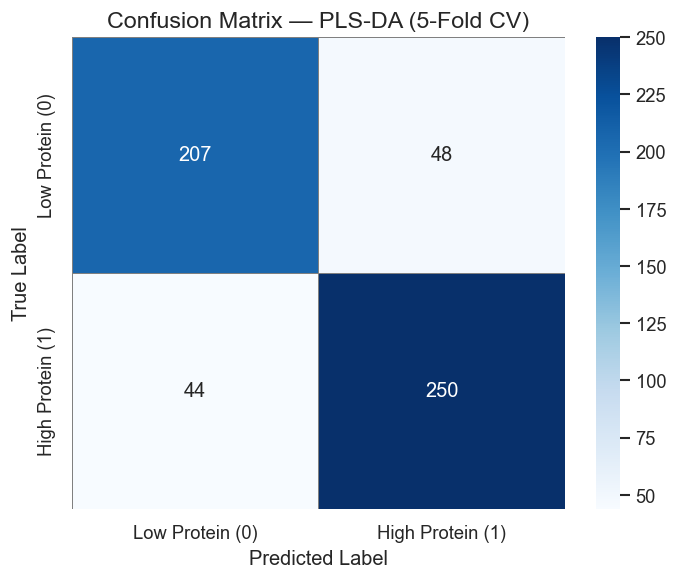

In [5]:
# ── Aggregate metrics across folds ───────────────────────────────────────────
mean_acc  = np.mean([m['accuracy']  for m in plsda_fold_metrics])
std_acc   = np.std( [m['accuracy']  for m in plsda_fold_metrics])
mean_prec = np.mean([m['precision'] for m in plsda_fold_metrics])
std_prec  = np.std( [m['precision'] for m in plsda_fold_metrics])
mean_rec  = np.mean([m['recall']    for m in plsda_fold_metrics])
std_rec   = np.std( [m['recall']    for m in plsda_fold_metrics])
mean_f1   = np.mean([m['f1']        for m in plsda_fold_metrics])
std_f1    = np.std( [m['f1']        for m in plsda_fold_metrics])

print("============================================")
print("  PLS-DA 5-Fold Cross Validation Results   ")
print("============================================")
print(f"  Accuracy  : {mean_acc:.4f} ± {std_acc:.4f}")
print(f"  Precision : {mean_prec:.4f} ± {std_prec:.4f}")
print(f"  Recall    : {mean_rec:.4f} ± {std_rec:.4f}")
print(f"  F1-Score  : {mean_f1:.4f} ± {std_f1:.4f}")
print("============================================")

# ── Aggregated confusion matrix over all folds ────────────────────────────────
y_true_all_plsda = np.concatenate(plsda_all_y_true)
y_pred_all_plsda = np.concatenate(plsda_all_y_pred)
plot_confusion_matrix(y_true_all_plsda, y_pred_all_plsda, model_name='PLS-DA (5-Fold CV)')

### 4c — Save Best PLS-DA Model (Bundled)

The PLS-DA model is saved in the same bundle format as the SVM model for
consistency. The `scaler` field is `None` since PLS-DA does not require
`StandardScaler` normalization. This consistent format makes `inference.py`
simpler — it always expects the same bundle structure regardless of model type.

In [6]:
import os
import joblib

os.makedirs('../../saved_models/revised', exist_ok=True)

# Bundle PLS-DA model with model_type for consistent loading in inference.py
plsda_bundle = {
    'model': plsda_best_model,
    'scaler': None,
    'model_type': 'PLS-DA'
}
joblib.dump(plsda_bundle, '../../saved_models/revised/pls_da_best.pkl')
print("PLS-DA bundle saved to: saved_models/revised/pls_da_best.pkl")
print("Bundle contains: model + model_type (no scaler needed for PLS-DA)")
print(f"Best fold F1-score: {plsda_best_f1:.4f}")

PLS-DA bundle saved to: saved_models/revised/pls_da_best.pkl
Bundle contains: model + model_type (no scaler needed for PLS-DA)
Best fold F1-score: 0.8871


---
## Section 5 — SVM 5-Fold Cross Validation

**Support Vector Machine (SVM)** with an RBF kernel maps spectral features into a high-dimensional space to find the maximum-margin hyperplane separating High-Protein and Low-Protein classes. It is well-suited for small, high-dimensional datasets typical in NIR spectroscopy.

Two important design choices are applied **inside each fold** to prevent data leakage:

1. **`StandardScaler`** is fitted on the augmented training data only. Both the augmented training data and the raw test fold are then transformed using that scaler. The scaler from the best fold is saved alongside the model so test-time predictions are correctly scaled.
2. **`GridSearchCV`** with inner 10-fold cross validation optimises the RBF hyperparameters `C` and `gamma` on the augmented training data before the model is evaluated on the held-out test fold.

### 5a — SVM CV Loop

Each outer fold follows the same structure as the PLS-DA loop: split → augment → scale → grid search → train → evaluate. The scaler fitted on the augmented training fold is stored so that test-time inference applies identical normalization.

In [7]:
# ── Accumulators ─────────────────────────────────────────────────────────────
svm_fold_metrics  = []
svm_best_model    = None
svm_best_scaler   = None
svm_best_f1       = 0.0
svm_all_y_true    = []
svm_all_y_pred    = []

# ── Hyperparameter search space ───────────────────────────────────────────────
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf'],
}

# ── Outer 5-Fold Loop ─────────────────────────────────────────────────────────
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    # 1. Split
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # 2. Augment ONLY the training fold
    X_aug, y_aug = interpolation_augment(
        X_train_fold, y_train_fold,
        target_total=2000,
        random_state=random_state,
    )

    # 3. Scale — fit on augmented training data, transform both splits
    scaler = StandardScaler()
    X_aug_scaled  = scaler.fit_transform(X_aug)
    X_test_scaled = scaler.transform(X_test_fold)

    # 4. Inner GridSearchCV (10-fold) on augmented scaled training data
    grid = GridSearchCV(
        SVC(random_state=random_state),
        param_grid,
        cv=10,
        scoring='f1',
        n_jobs=-1,
    )
    grid.fit(X_aug_scaled, y_aug)

    # 5. Retrain best SVM on the full augmented scaled training fold
    svm = SVC(**grid.best_params_, random_state=random_state)
    svm.fit(X_aug_scaled, y_aug)

    # 6. Predict on the original (scaled) test fold
    y_pred = svm.predict(X_test_scaled)

    # 7. Compute metrics
    acc  = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred, zero_division=0)
    rec  = recall_score(y_test_fold, y_pred, zero_division=0)
    f1   = f1_score(y_test_fold, y_pred, zero_division=0)

    print(
        f"Fold {fold+1}: "
        f"Accuracy={acc:.4f}  Precision={prec:.4f}  "
        f"Recall={rec:.4f}  F1={f1:.4f}  "
        f"Best params={grid.best_params_}"
    )

    # 8. Store results
    svm_fold_metrics.append({
        'accuracy': acc, 'precision': prec,
        'recall': rec,   'f1': f1,
    })
    svm_all_y_true.append(y_test_fold)
    svm_all_y_pred.append(y_pred)

    # 9. Keep model and scaler from the fold with the highest F1
    if f1 > svm_best_f1:
        svm_best_f1     = f1
        svm_best_model  = svm
        svm_best_scaler = scaler

print(f"\nBest SVM fold F1 : {svm_best_f1:.4f}")

Interpolation Augmentation
Original training size          : 439
Synthetic samples to generate   : 1561
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 943 samples
  1 (High Protein): 1057 samples
Fold 1: Accuracy=0.7909  Precision=0.7500  Recall=0.9153  F1=0.8244  Best params={'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Interpolation Augmentation
Original training size          : 439
Synthetic samples to generate   : 1561
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 942 samples
  1 (High Protein): 1058 samples
Fold 2: Accuracy=0.7636  Precision=0.7797  Recall=0.7797  F1=0.7797  Best params={'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Interpolation Augmentation
Original training size          : 439
Synthetic samples to generate   : 1561
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 949 samples
  1 (High Protein): 

### 5b — SVM Results Summary

Mean and standard deviation are computed across all 5 folds and printed in the same format as PLS-DA for direct comparison. The combined confusion matrix aggregates predictions from all 5 test folds.

   SVM 5-Fold Cross Validation Results     
  Accuracy  : 0.7650 ± 0.0163
  Precision : 0.7592 ± 0.0109
  Recall    : 0.8229 ± 0.0552
  F1-Score  : 0.7886 ± 0.0222


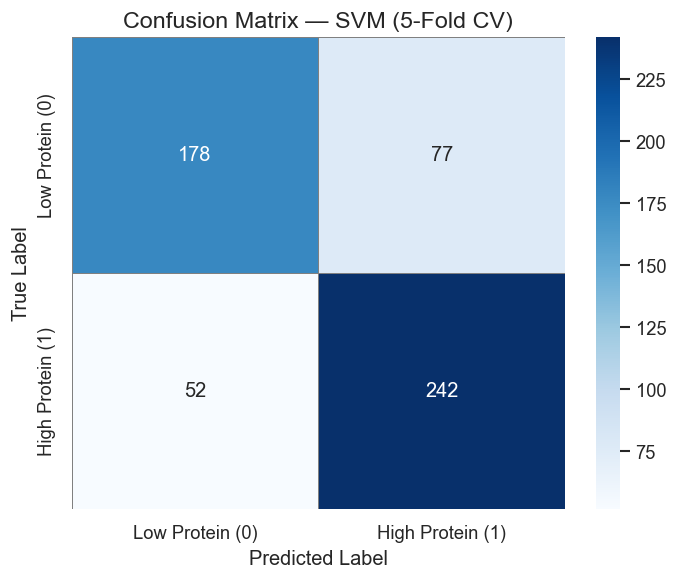

In [8]:
# ── Aggregate metrics across folds ───────────────────────────────────────────
svm_mean_acc  = np.mean([m['accuracy']  for m in svm_fold_metrics])
svm_std_acc   = np.std( [m['accuracy']  for m in svm_fold_metrics])
svm_mean_prec = np.mean([m['precision'] for m in svm_fold_metrics])
svm_std_prec  = np.std( [m['precision'] for m in svm_fold_metrics])
svm_mean_rec  = np.mean([m['recall']    for m in svm_fold_metrics])
svm_std_rec   = np.std( [m['recall']    for m in svm_fold_metrics])
svm_mean_f1   = np.mean([m['f1']        for m in svm_fold_metrics])
svm_std_f1    = np.std( [m['f1']        for m in svm_fold_metrics])

print("============================================")
print("   SVM 5-Fold Cross Validation Results     ")
print("============================================")
print(f"  Accuracy  : {svm_mean_acc:.4f} ± {svm_std_acc:.4f}")
print(f"  Precision : {svm_mean_prec:.4f} ± {svm_std_prec:.4f}")
print(f"  Recall    : {svm_mean_rec:.4f} ± {svm_std_rec:.4f}")
print(f"  F1-Score  : {svm_mean_f1:.4f} ± {svm_std_f1:.4f}")
print("============================================")

# ── Aggregated confusion matrix over all folds ────────────────────────────────
y_true_all_svm = np.concatenate(svm_all_y_true)
y_pred_all_svm = np.concatenate(svm_all_y_pred)
plot_confusion_matrix(y_true_all_svm, y_pred_all_svm, model_name='SVM (5-Fold CV)')

### 5c — Save Best SVM Model (Bundled with Scaler)

The best SVM model and its `StandardScaler` are saved together as a single
`.pkl` file. Bundling them ensures the scaler is always available alongside
the model regardless of where the application is deployed — no hardcoded
file paths are needed.

In [9]:
import os
import joblib

os.makedirs('../../saved_models/revised', exist_ok=True)

# Bundle model and scaler together into one file
# This ensures the scaler is always available wherever the model is deployed
svm_bundle = {
    'model': svm_best_model,
    'scaler': svm_best_scaler,
    'model_type': 'SVM'
}
joblib.dump(svm_bundle, '../../saved_models/revised/svm_best.pkl')
print("SVM bundle saved to: saved_models/revised/svm_best.pkl")
print("Bundle contains: model + scaler + model_type")
print(f"Best fold F1-score: {svm_best_f1:.4f}")

SVM bundle saved to: saved_models/revised/svm_best.pkl
Bundle contains: model + scaler + model_type
Best fold F1-score: 0.8244


---
## Section 6 — Compare PLS-DA vs SVM

The table and chart below summarize the cross-validated performance of both models side by side. Error bars in the bar chart represent the standard deviation across the 5 folds, giving the thesis panel a sense of how stable each model's performance is across different data partitions.

,Accuracy,Accuracy Std,Precision,Precision Std,Recall,Recall Std,F1-Score,F1 Std
Model,,,,,,,,
PLS-DA,0.8324,0.0340,0.8383,0.0174,0.8503,0.0563,0.8437,0.0351
SVM,0.7650,0.0163,0.7592,0.0109,0.8229,0.0552,0.7886,0.0222


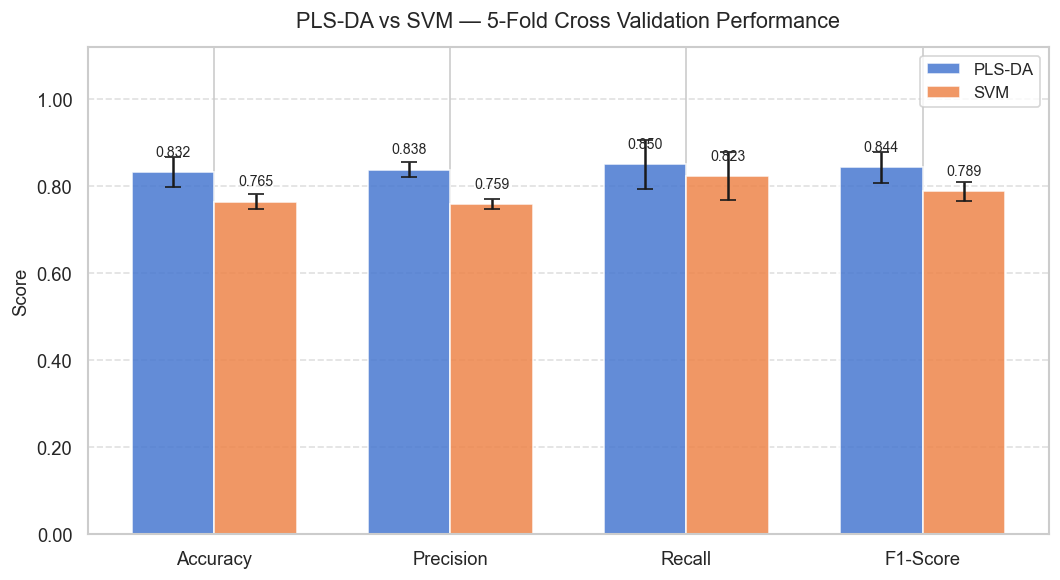

In [10]:
# ── Summary DataFrame ─────────────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {
        'Model':         'PLS-DA',
        'Accuracy':      mean_acc,
        'Accuracy Std':  std_acc,
        'Precision':     mean_prec,
        'Precision Std': std_prec,
        'Recall':        mean_rec,
        'Recall Std':    std_rec,
        'F1-Score':      mean_f1,
        'F1 Std':        std_f1,
    },
    {
        'Model':         'SVM',
        'Accuracy':      svm_mean_acc,
        'Accuracy Std':  svm_std_acc,
        'Precision':     svm_mean_prec,
        'Precision Std': svm_std_prec,
        'Recall':        svm_mean_rec,
        'Recall Std':    svm_std_rec,
        'F1-Score':      svm_mean_f1,
        'F1 Std':        svm_std_f1,
    },
])

display(comparison_df.set_index('Model').round(4))

# ── Grouped bar chart ─────────────────────────────────────────────────────────
metric_names   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plsda_means    = [mean_acc,     mean_prec,     mean_rec,     mean_f1]
plsda_stds     = [std_acc,      std_prec,      std_rec,      std_f1]
svm_means      = [svm_mean_acc, svm_mean_prec, svm_mean_rec, svm_mean_f1]
svm_stds       = [svm_std_acc,  svm_std_prec,  svm_std_rec,  svm_std_f1]

x      = np.arange(len(metric_names))
width  = 0.35
colors = sns.color_palette('muted', 2)

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width / 2, plsda_means, width,
    yerr=plsda_stds, capsize=5,
    label='PLS-DA', color=colors[0], alpha=0.85,
)
bars2 = ax.bar(
    x + width / 2, svm_means, width,
    yerr=svm_stds, capsize=5,
    label='SVM', color=colors[1], alpha=0.85,
)

ax.set_title('PLS-DA vs SVM — 5-Fold Cross Validation Performance', fontsize=13, pad=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8.5,
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8.5,
    )

plt.tight_layout()
plt.show()

In [11]:
# ── Identify the better model by mean F1 ─────────────────────────────────────
better_model  = 'SVM' if svm_mean_f1 >= mean_f1 else 'PLS-DA'
better_f1     = max(svm_mean_f1, mean_f1)
margin        = abs(svm_mean_f1 - mean_f1)

print("============================================")
print("  Model Comparison (by mean F1-Score)       ")
print("============================================")
print(f"  PLS-DA mean F1 : {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  SVM    mean F1 : {svm_mean_f1:.4f} ± {svm_std_f1:.4f}")
print(f"  Better model   : {better_model} (ΔF1 = {margin:.4f})")
print("============================================")

  Model Comparison (by mean F1-Score)       
  PLS-DA mean F1 : 0.8437 ± 0.0351
  SVM    mean F1 : 0.7886 ± 0.0222
  Better model   : PLS-DA (ΔF1 = 0.0551)


---
## Section 7 — Summary

### What this notebook did

| Item | Detail |
|---|---|
| **Evaluation method** | 5-Fold Stratified Cross Validation |
| **Dataset** | 80 original NIR spectra (40 High-Protein, 40 Low-Protein) |
| **Each outer fold** | 64 training samples → augmented to **2,000**; 16 test samples kept original and never augmented |
| **Data leakage prevention** | Augmentation, scaling, and hyperparameter tuning all occur strictly inside the training fold of each iteration |
| **PLS-DA tuning** | Optimal `n_components` selected via inner 10-fold CV on augmented training fold (range 1–20, scored by F1) |
| **SVM tuning** | `C` and `gamma` optimised via `GridSearchCV` with inner 10-fold CV on scaled augmented training fold |
| **Reported metrics** | Mean ± standard deviation across 5 folds (Accuracy, Precision, Recall, F1-Score) |
| **Best model criterion** | Fold with the highest F1-score on its held-out test split |

### Output artifacts

| File | Contents |
|---|---|
| `saved_models/revised/pls_da_best.pkl` | Best `PLSRegression` model across all folds |
| `saved_models/revised/svm_best.pkl` | Best `SVC` model across all folds |
| `saved_models/revised/svm_scaler.pkl` | `StandardScaler` paired with the best SVM fold |

### Next step

**`notebooks/revised/06_1d_cnn_revised.ipynb`** — applies the same 5-Fold Stratified CV strategy to the 1D Convolutional Neural Network, augmenting inside each fold and reporting mean ± std metrics for a fair three-way comparison with PLS-DA and SVM.

## Save Per-Fold Metrics to Disk

Per-fold metrics and combined predictions from all 5 folds are saved
as JSON files so that notebook 07 can load them for the final
benchmarking comparison without needing to retrain the models.

In [12]:
import json
import os

os.makedirs('../../data/results', exist_ok=True)

# Save PLS-DA results
plsda_results = {
    'model': 'PLS-DA',
    'fold_metrics': plsda_fold_metrics,
    'mean_accuracy':  float(np.mean([m['accuracy']  for m in plsda_fold_metrics])),
    'std_accuracy':   float(np.std( [m['accuracy']  for m in plsda_fold_metrics])),
    'mean_precision': float(np.mean([m['precision'] for m in plsda_fold_metrics])),
    'std_precision':  float(np.std( [m['precision'] for m in plsda_fold_metrics])),
    'mean_recall':    float(np.mean([m['recall']    for m in plsda_fold_metrics])),
    'std_recall':     float(np.std( [m['recall']    for m in plsda_fold_metrics])),
    'mean_f1':        float(np.mean([m['f1']        for m in plsda_fold_metrics])),
    'std_f1':         float(np.std( [m['f1']        for m in plsda_fold_metrics])),
    'all_y_true':     [int(v) for v in np.concatenate(plsda_all_y_true)],
    'all_y_pred':     [int(v) for v in np.concatenate(plsda_all_y_pred)],
}

with open('../../data/results/plsda_results.json', 'w') as f:
    json.dump(plsda_results, f, indent=2)
print("PLS-DA results saved to: data/results/plsda_results.json")

# Save SVM results
svm_results = {
    'model': 'SVM',
    'fold_metrics': svm_fold_metrics,
    'mean_accuracy':  float(np.mean([m['accuracy']  for m in svm_fold_metrics])),
    'std_accuracy':   float(np.std( [m['accuracy']  for m in svm_fold_metrics])),
    'mean_precision': float(np.mean([m['precision'] for m in svm_fold_metrics])),
    'std_precision':  float(np.std( [m['precision'] for m in svm_fold_metrics])),
    'mean_recall':    float(np.mean([m['recall']    for m in svm_fold_metrics])),
    'std_recall':     float(np.std( [m['recall']    for m in svm_fold_metrics])),
    'mean_f1':        float(np.mean([m['f1']        for m in svm_fold_metrics])),
    'std_f1':         float(np.std( [m['f1']        for m in svm_fold_metrics])),
    'all_y_true':     [int(v) for v in np.concatenate(svm_all_y_true)],
    'all_y_pred':     [int(v) for v in np.concatenate(svm_all_y_pred)],
}

with open('../../data/results/svm_results.json', 'w') as f:
    json.dump(svm_results, f, indent=2)
print("SVM results saved to: data/results/svm_results.json")

PLS-DA results saved to: data/results/plsda_results.json
SVM results saved to: data/results/svm_results.json
